In [1]:
from pathlib import Path
import pyvcell.vcml as vc
# import basico

# Model imported from VCell

In [2]:
biomodel = vc.load_vcml_url("https://raw.githubusercontent.com/virtualcell/pyvcell/refs/heads/main/examples/models/Tutorial_MultiApp_PDE.vcml")
model = biomodel.model
display(biomodel)
display(model.parameter_values)

Biomodel(model=Model(compartments=['cyt', 'nuc', 'EC', 'pm', 'nm'], species=['Ran_cyt', 'C_cyt', 'RanC_nuc', 'RanC_cyt'], reactions=['r0', 'flux0'], parameters=[]), applications=['3D pde'], simulations=['Simulation4'])

{'r0.J': '((Kf * RanC_cyt) - ((Kr * Ran_cyt) * C_cyt))',
 'r0.Kf': 1.0,
 'r0.Kr': 1000.0,
 'flux0.J': '(kfl * (RanC_cyt - RanC_nuc))',
 'flux0.I': 0.0,
 'flux0.netValence': 1.0,
 'flux0.kfl': 2.0}

In [3]:
model.set_parameter_value(name="r0.Kf", value=20.0)
display(model.parameter_values)

{'r0.J': '((Kf * RanC_cyt) - ((Kr * Ran_cyt) * C_cyt))',
 'r0.Kf': 20.0,
 'r0.Kr': 1000.0,
 'flux0.J': '(kfl * (RanC_cyt - RanC_nuc))',
 'flux0.I': 0.0,
 'flux0.netValence': 1.0,
 'flux0.kfl': 2.0}

# run N simulations with randomly sampled parameter values

In [4]:
import numpy as np

# make mesh smaller to make it run faster - was (100, 100, 36)
sim = biomodel.applications[0].simulations[0]
sim.mesh_size = (50, 50, 18)

# take N samples from log-normal distibution for r0.Kf
N=5
r0_Kf_values = np.random.lognormal(mean=0, sigma=1.0, size=N)

# run N simulations and store results
all_results = []
for val in r0_Kf_values:
    model.set_parameter_value("r0.Kf", val)
    print(f"running sim with r0.Kf={val}")
    all_results.append(vc.simulate(biomodel, sim.name))

running sim with r0.Kf=1.141026225369187
Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T17:32:22.776605Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T17:32:22.780981Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@4800be12 and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T17:32:23.101410Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@4800be12 and is now requeste

Simulation Complete in Main() ... 


running sim with r0.Kf=0.7014492480373434
Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T17:32:25.319253Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T17:32:25.322936Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@6825df89 and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T17:32:25.644905Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@6825df89 and is now request

Simulation Complete in Main() ... 


--------------- sim summary ----------------
Cartesian Mesh: Domain    x:[0,74.24] y:[0,74.24] z:[0,26]
                Elements  numX=50 numY=50 numZ=18

	time = 10 sec
	dT   = 0.1 sec
--------------------------------------------
Setting Base file name to: `"/Users/jimschaff/Documents/workspace/pyvcell/examples/notebooks/workspace/out_dir_zt_tq2gx/SimID_1428354083_0_"`
initializing mesh
numVolume=45000

CartesianMesh::computeNormalsFromNeighbors(), compute normals from neighbors
Membrane Elements -> N=3864
--------Num of points that have zero neighbors 0
--------Num Neighbors before symmetrize 22879
--------Num Neighbors after symmetrize 25874
Total volume=5693.300679
Total FluxArea =36.30610318
Total FluxAreaXM =0
Total FluxAreaXP =0
Total FluxAreaYM =20.00887821
Total FluxAreaYP =16.29722497
Total FluxAreaZM =0
Total FluxAreaZP =0
mesh initialized
preprocessing finished
pdeCount=4, odeCount=0
No log-file found at constructed path `/Users/jimschaff/Documents/workspace/pyvcell/example

Simulation Complete in Main() ... 


running sim with r0.Kf=2.2465655042311234
Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T17:32:30.419649Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T17:32:30.423282Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@71eca528 and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T17:32:30.732015Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@71eca528 and is now request

Simulation Complete in Main() ... 


running sim with r0.Kf=0.3413035997885732
Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T17:32:32.939935Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T17:32:32.943577Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@36f90b5f and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T17:32:33.295897Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@36f90b5f and is now request

Simulation Complete in Main() ... 


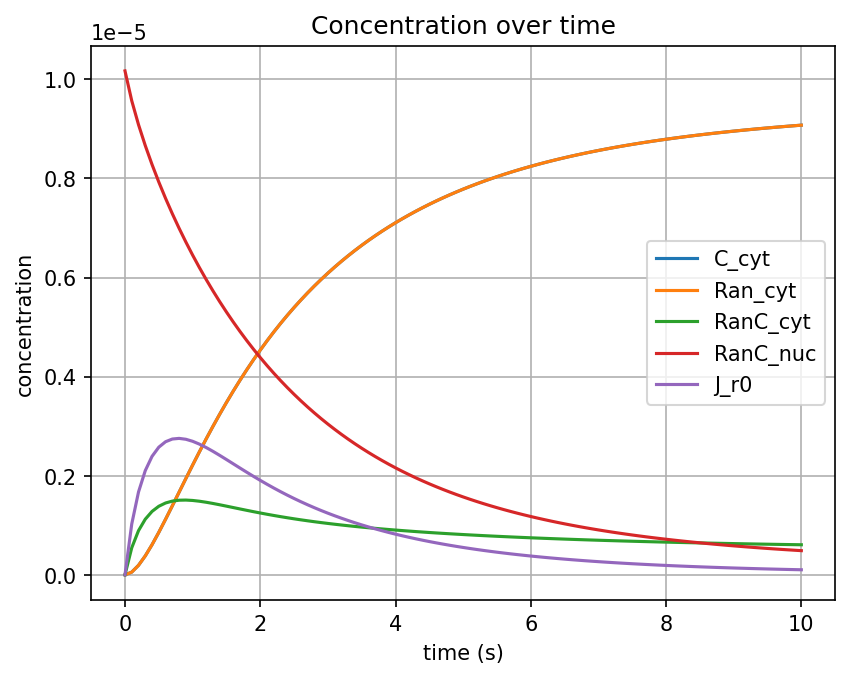

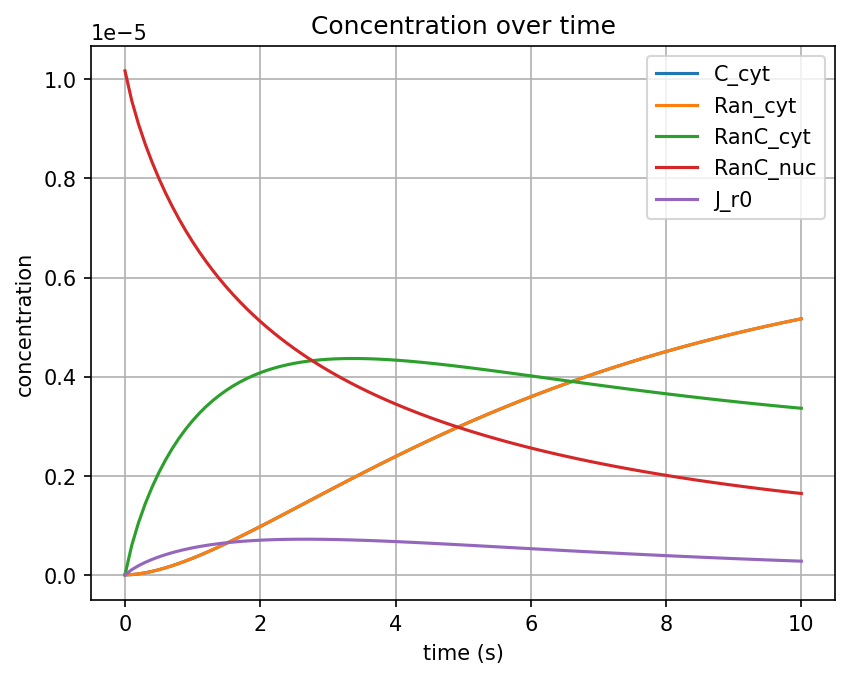

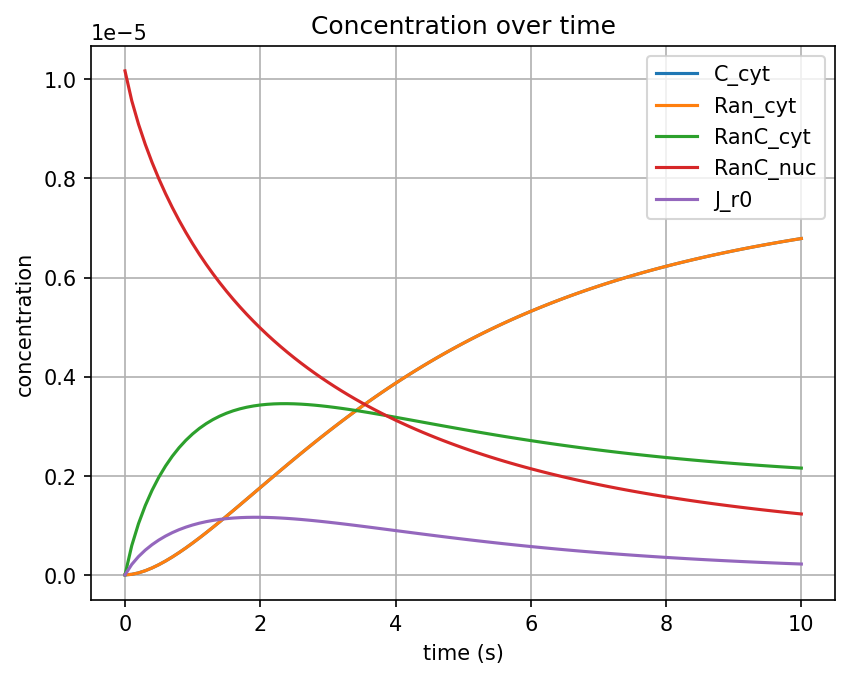

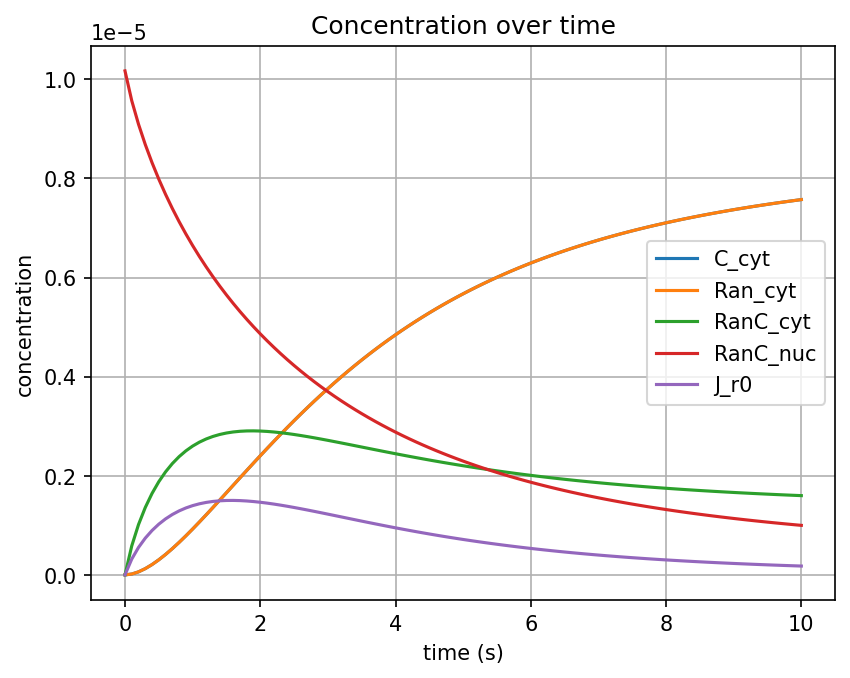

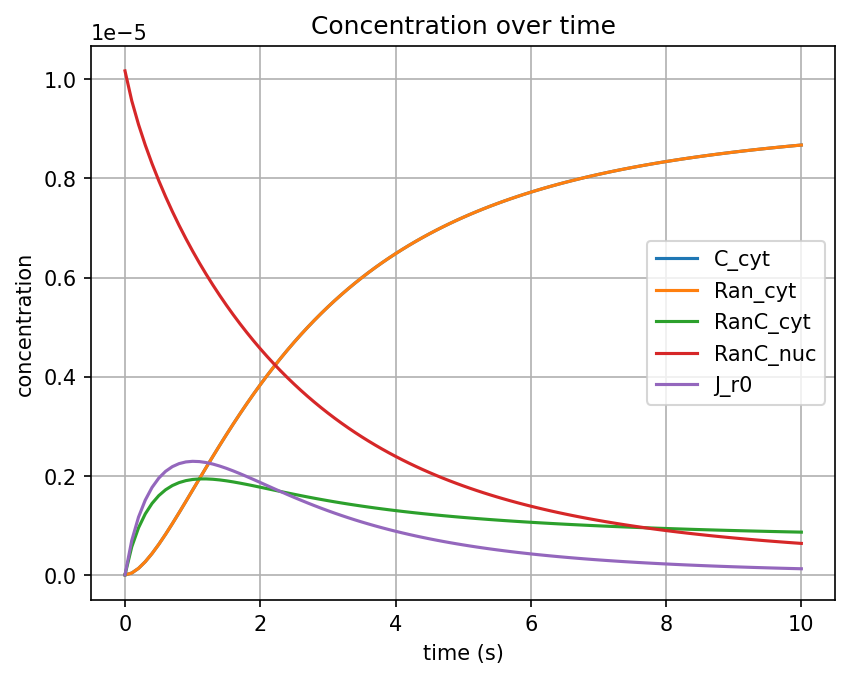

In [13]:
for i in range(N):
    val = r0_Kf_values[i]
    result = all_results[i]
    print(f"r0.Kf={val}")
    result.plotter.plot_concentrations()